Import libraries

In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Load data

In [4]:
iris = load_iris()
iris_x = iris.data[:-1, :]
iris_y = iris.target[:-1]
iris_y = pd.get_dummies(iris_y).values
train_x, test_x, train_y, test_y = train_test_split(iris_x, iris_y, test_size=0.33, random_state=42)

In [6]:
num_features = train_x.shape[1]
print('no of features:', num_features)

num_labels = train_y.shape[1]
print('num of labels is:', num_labels)

no of features: 4
num of labels is: 3


In [8]:
X = tf.Variable( np.identity(num_features), tf.TensorShape(num_features),dtype='float32') # Iris has 4 features, so X is a tensor to hold our data.
yGold = tf.Variable(np.array([1,1,1]),shape=tf.TensorShape(num_labels),dtype='float32') # This will be our correct answers matrix for 3 classes.

In [9]:
X

<tf.Variable 'Variable:0' shape=(4, 4) dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]], dtype=float32)>

In [10]:
yGold

<tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([1., 1., 1.], dtype=float32)>

In [11]:
train_x = tf.constant(train_x, dtype='float32')
test_x = tf.constant(test_x, dtype='float32')
train_y = tf.constant(train_y, dtype='float32')
test_y = tf.constant(test_y, dtype='float32')

Set model weights and bias

In [12]:
W = tf.Variable(tf.zeros([4,3])) # 4-dimensional input and  3 classes
b = tf.Variable(tf.zeros([3])) # 3-dimensional output [0,0,1],[0,1,0],[1,0,0]

Randomly sample from a normal distribution with standard deviation .01

In [15]:
weights = tf.Variable(tf.random.normal([num_features, num_labels],
                                       mean=0, 
                                       stddev=0.01,
                                       name='weights'), dtype='float32')

bias = tf.Variable(tf.random.normal([1, num_labels],
                                    mean=0,
                                    stddev=0.01,
                                    name='bais'))
                                      

Logistic Regression model

In [17]:
def logistic_regression(x):
    apply_weights_OP = tf.matmul(x, weights, name="apply_weights")
    add_bias_OP = tf.add(apply_weights_OP, bias, name="add_bias")
    activation_OP = tf.nn.sigmoid(add_bias_OP, name="activation")
    return activation_OP

Cost Function

In [20]:
numEpochs = 700

learningRate = tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=0.001,
                decay_steps=train_x.shape[0],
                decay_rate = 0.9,
                staircase=True)

In [21]:
loss_object = tf.keras.losses.MeanSquaredLogarithmicError()
optimizer = tf.keras.optimizers.SGD(learningRate)

Accuracy 

In [22]:
def accuracy(y_pred, y_true):
    correct_prediction = tf.equal(tf.argmax(y_pred, 1), tf.argmax(y_true, 1))
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

Optimization Process

In [25]:
def run_optimization(x, y):
    with tf.GradientTape() as g:
        pred = logistic_regression(x)
        loss = loss_object(pred, y)

    gradients = g.gradient(loss, [weights, bias])
    optimizer.apply_gradients(zip(gradients, [weights, bias]))

Training

In [28]:
# Initialize reporting variables
display_step = 10
epoch_values = []
accuracy_values = []
loss_values = []
loss = 0
diff = 1
# Training epochs
for i in range(numEpochs):
    if i > 1 and diff < .0001:
        print("change in loss %g; convergence."%diff)
        break
    else:
        # Run training step
        run_optimization(train_x, train_y)
        
        # Report occasional stats
        if i % display_step == 0:
            # Add epoch to epoch_values
            epoch_values.append(i)
            
            pred = logistic_regression(test_x)

            newLoss = loss_object(pred, test_y)
            # Add loss to live graphing variable
            loss_values.append(newLoss)
            
            # Generate accuracy stats on test data
            acc = accuracy(pred, test_y)
            accuracy_values.append(acc)
            
    
            # Re-assign values for variables
            diff = abs(newLoss - loss)
            loss = newLoss

            #generate print statements
            print("step %d, training accuracy %g, loss %g, change in loss %g"%(i, acc, newLoss, diff))

        

          

# How well do we perform on held-out test data?
print("final accuracy on test set: %s" %acc.numpy())


step 0, training accuracy 0.32, loss 0.14145, change in loss 0.14145
step 10, training accuracy 0.32, loss 0.140643, change in loss 0.000806838
step 20, training accuracy 0.32, loss 0.139849, change in loss 0.000793889
step 30, training accuracy 0.32, loss 0.139069, change in loss 0.000780866
step 40, training accuracy 0.32, loss 0.138301, change in loss 0.000767753
step 50, training accuracy 0.32, loss 0.137546, change in loss 0.000754625
step 60, training accuracy 0.32, loss 0.136805, change in loss 0.000741422
step 70, training accuracy 0.32, loss 0.136076, change in loss 0.000728235
step 80, training accuracy 0.32, loss 0.135361, change in loss 0.000715032
step 90, training accuracy 0.32, loss 0.13466, change in loss 0.00070186
step 100, training accuracy 0.32, loss 0.133985, change in loss 0.000675067
step 110, training accuracy 0.32, loss 0.133376, change in loss 0.000608832
step 120, training accuracy 0.32, loss 0.132777, change in loss 0.000598267
step 130, training accuracy 0

Visualization

C:\Users\ANAND\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ANAND\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


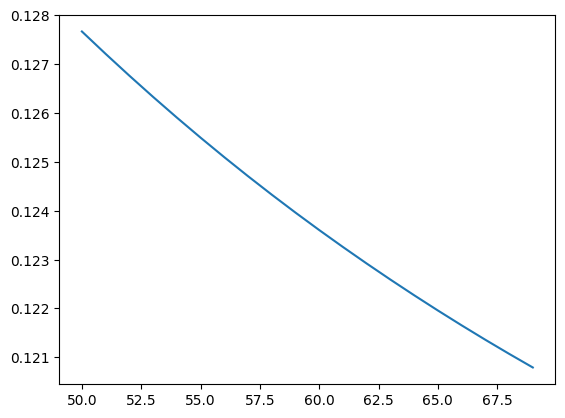

In [30]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.plot([np.mean(loss_values[i-50:i]) for i in range(len(loss_values))])
plt.show()